In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset='/content/drive/MyDrive/Python Project/yahoo_data.xlsx'
all='/content/drive/MyDrive/Python Project/Apple_Tesla_Samsung.xlsx'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_excel(dataset)
df.head()

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [ ]:
df_all= pd.read_excel(all)
df_all.head()

,Company,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,Apple,AAPL,2018-01-02,42.540001,43.075001,42.314999,43.064999,40.722874,102223600
1,Apple,AAPL,2018-01-03,43.132500,43.637501,42.990002,43.057499,40.715778,118071600
2,Apple,AAPL,2018-01-04,43.134998,43.367500,43.020000,43.257500,40.904907,89738400
3,Apple,AAPL,2018-01-05,43.360001,43.842499,43.262501,43.750000,41.370621,94640000
4,Apple,AAPL,2018-01-08,43.587502,43.902500,43.482498,43.587502,41.216961,82271200


In [ ]:
df.info()
df.describe()
df_all.info()
df_all.describe()

# Checking for missing values
missing_values = df.isnull().sum()
missing_values_all=df_all.isnull().sum()
print("Missing Values:\n", missing_values)
print("Missing Values:\n", missing_values_all)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1258 non-null   object 
 1   Open         1258 non-null   float64
 2   High         1258 non-null   float64
 3   Low          1258 non-null   float64
 4   Close*       1258 non-null   float64
 5   Adj Close**  1258 non-null   float64
 6   Volume       1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4493 entries, 0 to 4492
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Company    4493 non-null   object        
 1   Ticker     4493 non-null   object        
 2   Date       4493 non-null   datetime64[ns]
 3   Open       4493 non-null   float64       
 4   High       4493 non-null   float64       
 5   Low        44

In [ ]:
print(df.columns)

# Clean column names: remove special characters and make them lowercase
df.rename(columns=lambda x: x.strip().replace('*', '').replace('**', '').lower(), inplace=True)

# Verify the cleaned column names
print(df.columns)
print("Missing Values:\n", df.isnull().sum())
print(df.describe())


Index(['Date', 'Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume'], dtype='object')
Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume'], dtype='object')
Missing Values:
 date         0
open         0
high         0
low          0
close        0
adj close    0
volume       0
dtype: int64
               open          high           low         close     adj close  \
count   1258.000000   1258.000000   1258.000000   1258.000000   1258.000000   
mean   29595.823045  29776.945739  29402.432226  29599.361677  29599.361677   
std     4006.078299   4009.007573   4004.949066   4007.468822   4007.468822   
min    19028.360000  19121.010000  18213.650000  18591.930000  18591.930000   
25%    26041.267500  26163.155000  25877.872500  26027.120000  26027.120000   
50%    29201.410000  29335.685000  28996.500000  29199.460000  29199.460000   
75%    33604.027500  33825.445000  33346.827500  33600.342500  33600.342500   
max    36722.600000  36952.650000  36636.000000  36799.6

In [ ]:
print(df_all.columns)

# Clean column names: remove special characters and make them lowercase
df_all.rename(columns=lambda x: x.strip().replace('*', '').replace('**', '').lower(), inplace=True)

# Verify the cleaned column names
print(df_all.columns)
print("Missing Values:\n", df_all.isnull().sum())
print(df_all.describe())


Index(['Company', 'Ticker', 'Date', 'Open', 'High', 'Low', 'Close',
       'Adj Close', 'Volume'],
      dtype='object')
Index(['company', 'ticker', 'date', 'open', 'high', 'low', 'close',
       'adj close', 'volume'],
      dtype='object')
Missing Values:
 company      0
ticker       0
date         0
open         0
high         0
low          0
close        0
adj close    0
volume       0
dtype: int64
                                date          open          high  \
count                           4493   4493.000000   4493.000000   
mean   2020-12-30 18:35:20.097929984  19862.334998  20039.106120   
min              2018-01-02 00:00:00     12.073333     12.445333   
25%              2019-07-03 00:00:00     66.394997     67.333336   
50%              2020-12-30 00:00:00    183.740005    186.380005   
75%              2022-07-01 00:00:00  48200.000000  48900.000000   
max              2023-12-29 00:00:00  90300.000000  96800.000000   
std                              NaN  29153.45329

**Concatenation of two data frames into one**

In [ ]:
print(df.columns)
print(df_all.columns)

Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'return',
       'rolling_volatility'],
      dtype='object')
Index(['company', 'ticker', 'date', 'open', 'high', 'low', 'close',
       'adj close', 'volume', 'return'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.lower().str.strip()
df_all.columns = df_all.columns.str.lower().str.strip()

In [ ]:
df['ticker'] = 'YAHOO'

In [ ]:
df = df[['date','open','high','low','close','volume','ticker']]
df_all = df_all[['date','open','high','low','close','volume','ticker']]

In [ ]:
combined_df = pd.concat([df, df_all], ignore_index=True)

In [ ]:
print(combined_df.head())
print(combined_df['ticker'].unique())
print(combined_df.shape)

        date      open      high       low     close     volume ticker
0 2018-05-01  24117.29  24117.29  23808.19  24099.05  380070000  YAHOO
1 2018-05-02  24097.63  24185.52  23886.30  23924.98  385350000  YAHOO
2 2018-05-03  23836.23  23996.15  23531.31  23930.15  389240000  YAHOO
3 2018-05-04  23865.22  24333.35  23778.87  24262.51  329480000  YAHOO
4 2018-05-07  24317.66  24479.45  24263.42  24357.32  307670000  YAHOO
['YAHOO' '005930.KS' 'AAPL' 'TSLA']
(5751, 7)


**Data Cleaning**

In [ ]:
combined_df['return'] = combined_df.groupby('ticker')['close'].pct_change()

In [ ]:
combined_df.columns = combined_df.columns.str.lower().str.strip()

In [ ]:
combined_df.columns = combined_df.columns.str.lower().str.strip()

combined_df['date'] = pd.to_datetime(combined_df['date'])

combined_df = combined_df.sort_values(['ticker', 'date'])

In [ ]:
print(combined_df.isnull().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
ticker    0
return    4
dtype: int64


In [ ]:
combined_df = combined_df.dropna(subset=['close', 'date', 'ticker'])

In [ ]:
combined_df = combined_df.drop_duplicates()
print(combined_df)

           date      open      high       low     close     volume     ticker  \
1258 2018-01-02  51380.00  51400.00  50780.00  51020.00    8474250  005930.KS   
1259 2018-01-03  52540.00  52560.00  51420.00  51620.00   10013500  005930.KS   
1260 2018-01-04  52120.00  52180.00  50640.00  51080.00   11695450  005930.KS   
1261 2018-01-05  51300.00  52120.00  51200.00  52120.00    9481150  005930.KS   
1262 2018-01-08  52400.00  52520.00  51500.00  52020.00    8383650  005930.KS   
...         ...       ...       ...       ...       ...        ...        ...   
1253 2023-04-24  33805.04  33891.15  33726.09  33875.40  252020000      YAHOO   
1254 2023-04-25  33828.34  33875.49  33525.39  33530.83  297880000      YAHOO   
1255 2023-04-26  33596.34  33645.83  33235.85  33301.87  321170000      YAHOO   
1256 2023-04-27  33381.66  33859.75  33374.65  33826.16  343240000      YAHOO   
1257 2023-04-28  33797.43  34104.56  33728.40  34098.16  354310000      YAHOO   

        return  
1258      

In [ ]:
cols = ['open','high','low','close','volume']

combined_df[cols] = combined_df[cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
#for remaining Nan values
combined_df = combined_df.dropna()

In [ ]:
# keep only common dates
pivot = combined_df.pivot(index='date', columns='ticker', values='close')
pivot = pivot.dropna()

In [ ]:
clean_df = pivot.reset_index().melt(id_vars='date', var_name='ticker', value_name='close')

In [ ]:
clean_df = clean_df.sort_values(['ticker','date'])

clean_df['return'] = clean_df.groupby('ticker')['close'].pct_change()

In [ ]:
clean_df = clean_df.dropna()

In [ ]:
print(clean_df.head())
print(clean_df['ticker'].unique())
print(clean_df.shape)

        date     ticker    close    return
1 2018-05-03  005930.KS  53000.0  0.000000
2 2018-05-04  005930.KS  51900.0 -0.020755
3 2018-05-08  005930.KS  52600.0  0.013487
4 2018-05-09  005930.KS  50900.0 -0.032319
5 2018-05-10  005930.KS  51600.0  0.013752
['005930.KS' 'AAPL' 'TSLA' 'YAHOO']
(4756, 4)


In [ ]:
print(clean_df.head())
print(clean_df.info())
print(clean_df.describe())

        date     ticker    close    return
1 2018-05-03  005930.KS  53000.0  0.000000
2 2018-05-04  005930.KS  51900.0 -0.020755
3 2018-05-08  005930.KS  52600.0  0.013487
4 2018-05-09  005930.KS  50900.0 -0.032319
5 2018-05-10  005930.KS  51600.0  0.013752
<class 'pandas.core.frame.DataFrame'>
Index: 4756 entries, 1 to 4759
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4756 non-null   datetime64[ns]
 1   ticker  4756 non-null   object        
 2   close   4756 non-null   float64       
 3   return  4756 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 185.8+ KB
None
                                date         close       return
count                           4756   4756.000000  4756.000000
mean   2020-10-31 09:37:41.732548352  22363.389727     0.001185
min              2018-05-03 00:00:00     11.931333    -0.210628
25%              2019-08-05 00:00:00    122

**EDA**

In [ ]:
#Check Number of Stocks & Time Range
print("Stocks:", clean_df['ticker'].unique())

print("Date Range:",
      clean_df['date'].min(),
      "to",
      clean_df['date'].max())


Stocks: []
Date Range: NaT to NaT


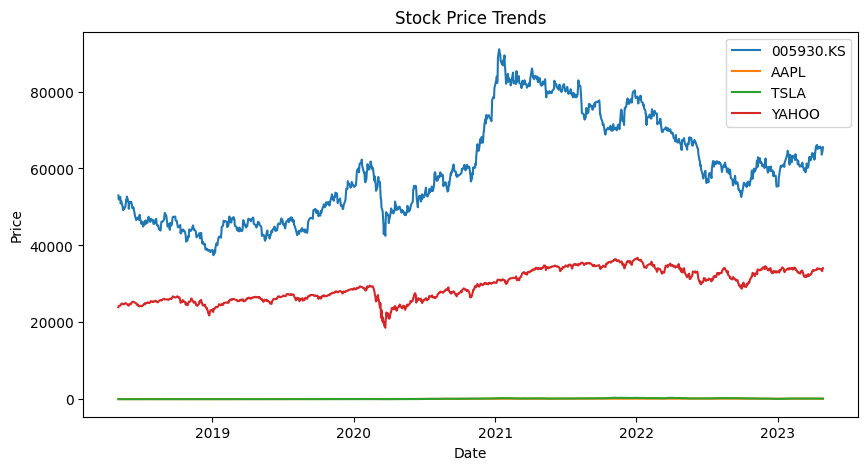

In [ ]:
#Price Trend Analysis
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['close'], label=stock)

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

###CHECKING THE DATA ONCE MORE

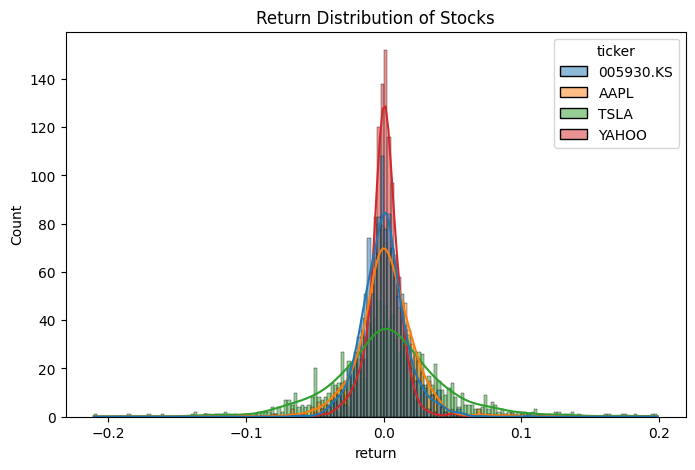

In [ ]:
#Return Distribution-->Return distributions reveal risk characteristics such as skewness and extreme movements.
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=clean_df, x='return', hue='ticker', kde=True)

plt.title("Return Distribution of Stocks")
plt.show()

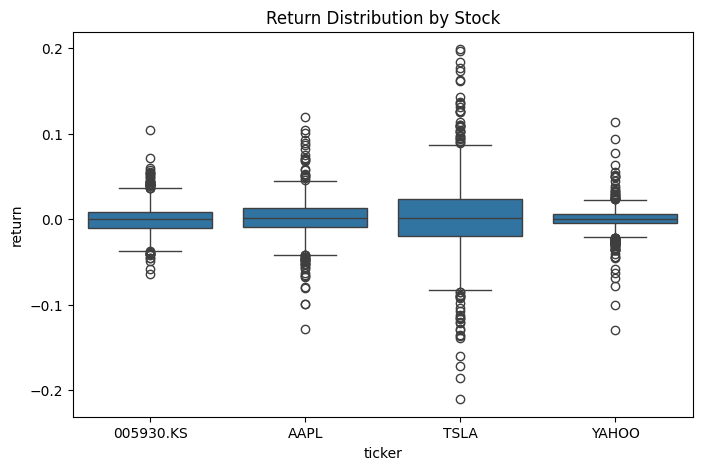

In [ ]:
#Boxplot (Compare Risk Visually)--> Wider spread indicates higher volatility (risk)
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_df, x='ticker', y='return')

plt.title("Return Distribution by Stock")
plt.show()


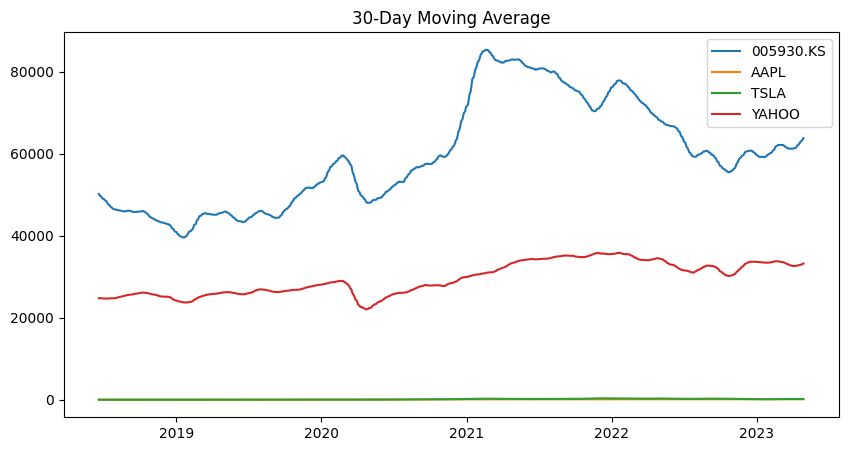

In [ ]:
#Rolling Mean (Trend Smoothing)
clean_df['rolling_mean'] = clean_df.groupby('ticker')['close'].transform(lambda x: x.rolling(30).mean())

plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['rolling_mean'], label=stock)

plt.title("30-Day Moving Average")
plt.legend()
plt.show()

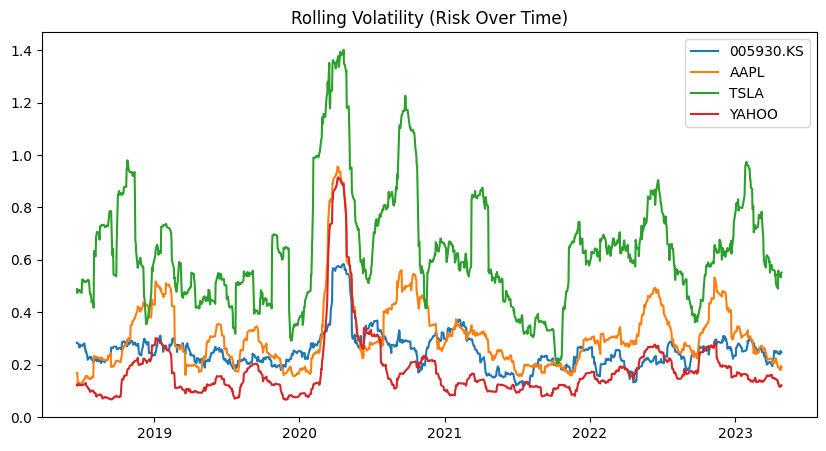

In [ ]:
#Rolling Volatility
clean_df['rolling_vol'] = clean_df.groupby('ticker')['return'].transform(lambda x: x.rolling(30).std() * (252**0.5))

plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['rolling_vol'], label=stock)

plt.title("Rolling Volatility (Risk Over Time)")
plt.legend()
plt.show()

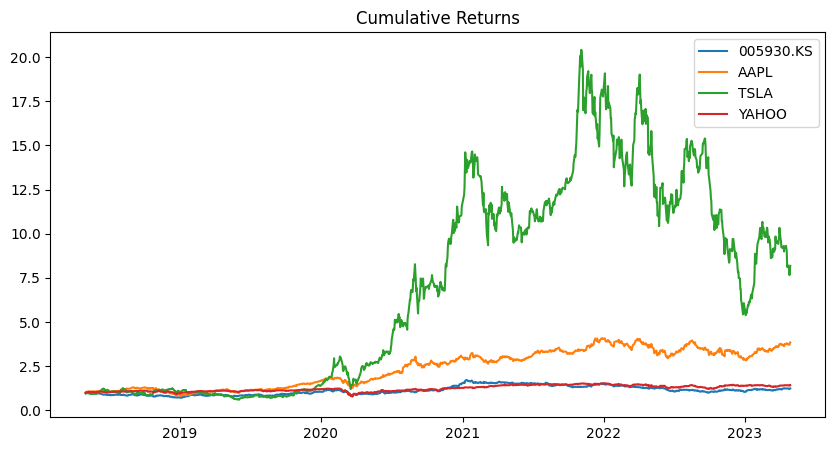

In [ ]:
#Cumulative Returns
clean_df['cumulative_return'] = clean_df.groupby('ticker')['return'].transform(lambda x: (1 + x).cumprod())

plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['cumulative_return'], label=stock)

plt.title("Cumulative Returns")
plt.legend()
plt.show()

Trends: Apple shows a steady upward trend, while Tesla exhibits higher fluctuations.

Returns: Return distributions indicate that Tesla has higher variance, suggesting greater risk.

Volatility:Rolling volatility highlights periods of market instability.

Performance:Cumulative returns indicate long-term profitability of each stock.

**RETURN ANALYSIS**

In [ ]:
# daily return calculation
clean_df['return'] = clean_df.groupby('ticker')['close'].pct_change()
clean_df = clean_df.dropna()

In [ ]:
#Average (Mean) Return per Stock
mean_return = clean_df.groupby('ticker')['return'].mean()
print(mean_return)
#annualized return
annual_return = mean_return * 252
print("Annual Returns:")
print(annual_return)


ticker
005930.KS    0.000420
AAPL         0.001349
TSLA         0.002590
YAHOO        0.000376
Name: return, dtype: float64
Annual Returns:
ticker
005930.KS    0.105874
AAPL         0.339863
TSLA         0.652683
YAHOO        0.094804
Name: return, dtype: float64


In [ ]:
#Cumulative Return
clean_df['cumulative_return'] = clean_df.groupby('ticker')['return'].transform(lambda x: (1 + x).cumprod())

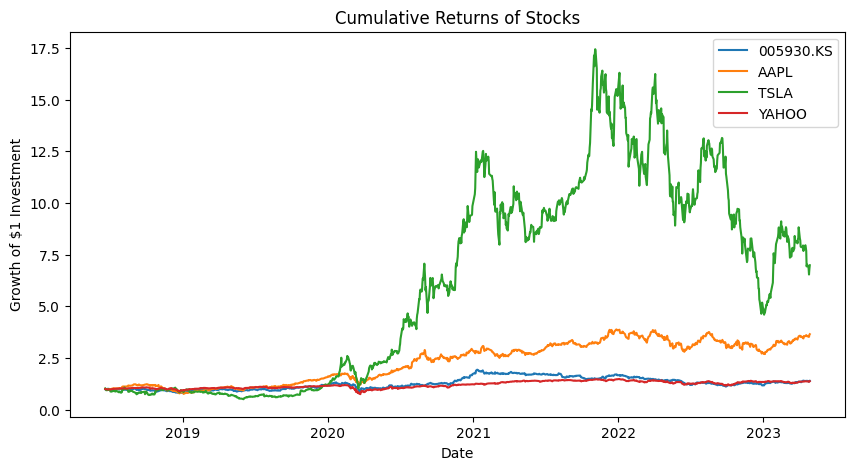

In [ ]:
plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['cumulative_return'], label=stock)

plt.title("Cumulative Returns of Stocks")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.show()

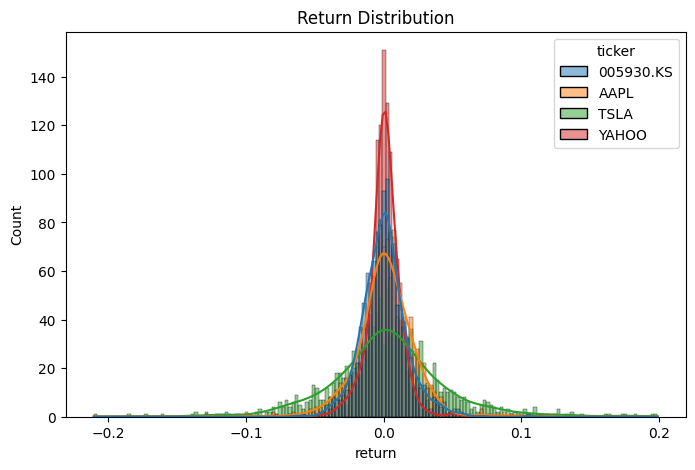

In [ ]:
#Return Distribution (Risk Insight)
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=clean_df, x='return', hue='ticker', kde=True)

plt.title("Return Distribution")
plt.show()

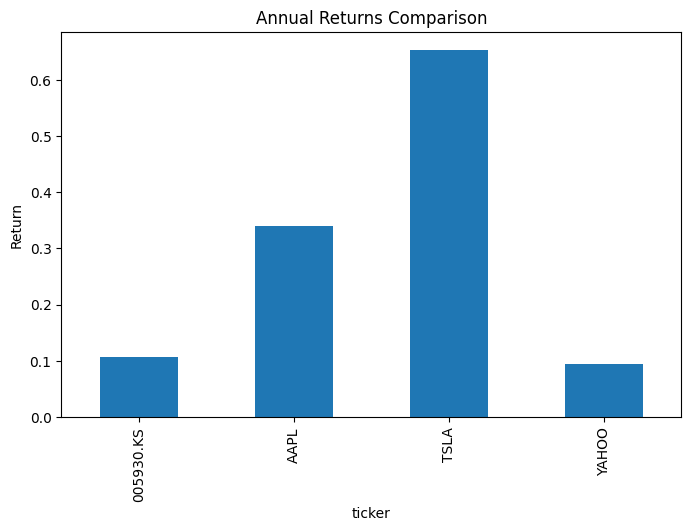

In [ ]:
#Compare Returns
annual_return.plot(kind='bar', figsize=(8,5), title="Annual Returns Comparison")
plt.ylabel("Return")
plt.show()

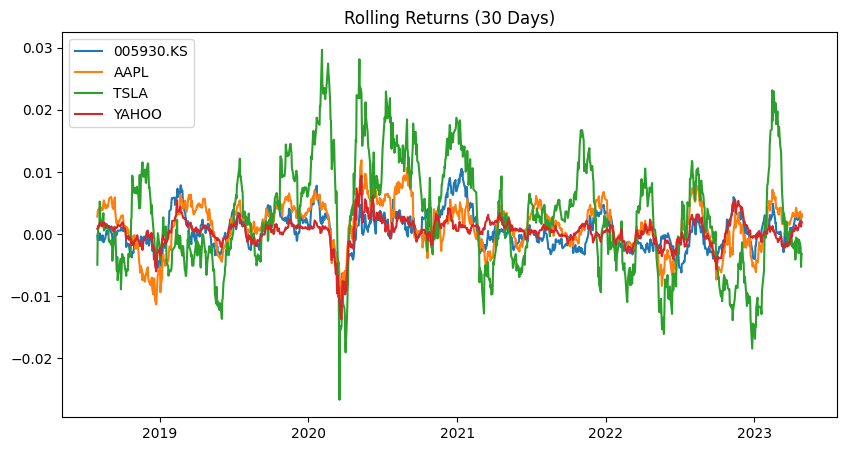

In [ ]:
#Rolling Returns
clean_df['rolling_return'] = clean_df.groupby('ticker')['return'].transform(lambda x: x.rolling(30).mean())

plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['rolling_return'], label=stock)

plt.title("Rolling Returns (30 Days)")
plt.legend()
plt.show()

Return Comparison: Tesla exhibits the highest average return, indicating strong growth potential.

Risk-Return Tradeoff: Higher returns are accompanied by greater volatility, reflecting increased risk.

Cumulative Returns: Even a hypothetical $1 investment in Apple shows steady growth compared to more volatile stocks.

Distribution: Return distributions reveal fat tails, indicating occasional extreme movements.

In [ ]:
#basic volatility per stock
volatility = clean_df.groupby('ticker')['return'].std()

print("Daily Volatility:")
print(volatility)

Daily Volatility:
ticker
005930.KS    0.016418
AAPL         0.021486
TSLA         0.042776
YAHOO        0.013980
Name: return, dtype: float64


In [ ]:
#annualized volatility
annual_volatility = volatility * (252 ** 0.5)
print("Annualized Volatility:")
print(annual_volatility)

Annualized Volatility:
ticker
005930.KS    0.260625
AAPL         0.341085
TSLA         0.679043
YAHOO        0.221932
Name: return, dtype: float64


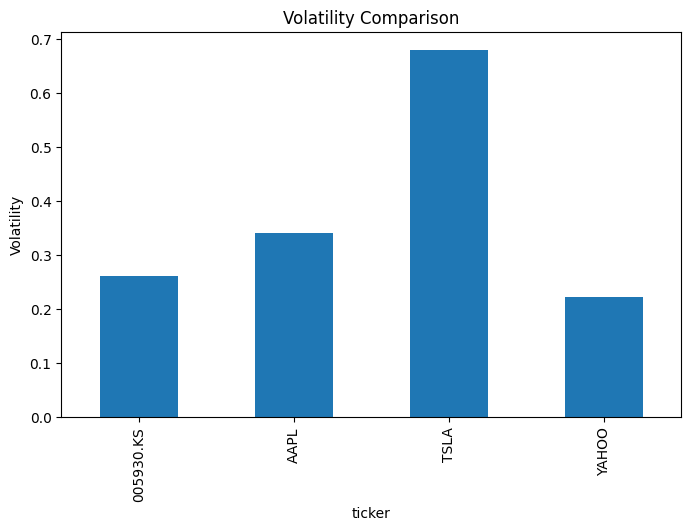

In [ ]:
#Compare Volatility
annual_volatility.plot(kind='bar', figsize=(8,5), title="Volatility Comparison")
plt.ylabel("Volatility")
plt.show()

In [ ]:
#Rolling Volatility
clean_df['rolling_vol'] = clean_df.groupby('ticker')['return'].transform(lambda x: x.rolling(30).std() * (252 ** 0.5))

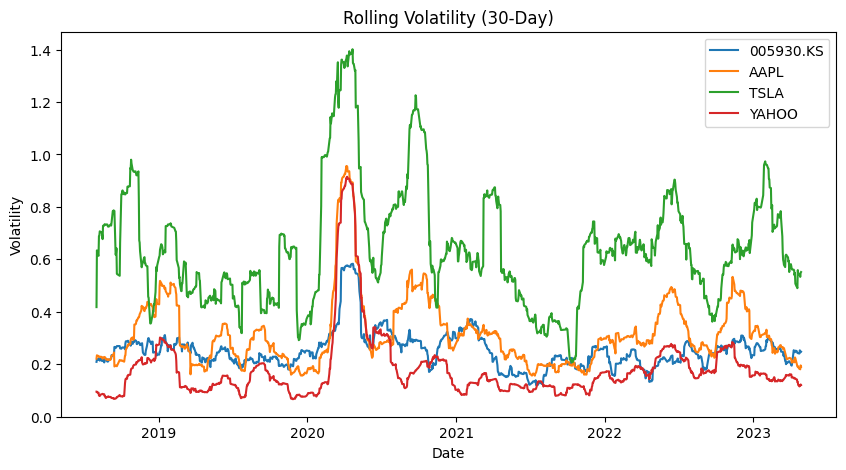

In [ ]:
#Plot Rolling Volatility
plt.figure(figsize=(10,5))

for stock in clean_df['ticker'].unique():
    temp = clean_df[clean_df['ticker'] == stock]
    plt.plot(temp['date'], temp['rolling_vol'], label=stock)

plt.title("Rolling Volatility (30-Day)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

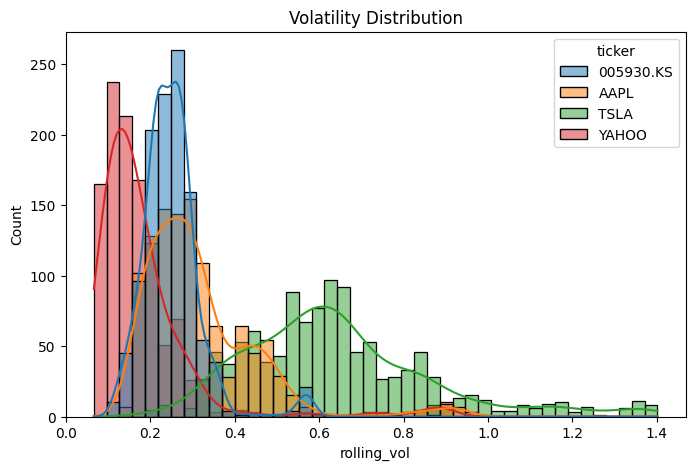

In [ ]:
#Volatility Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=clean_df, x='rolling_vol', hue='ticker', kde=True)

plt.title("Volatility Distribution")
plt.show()

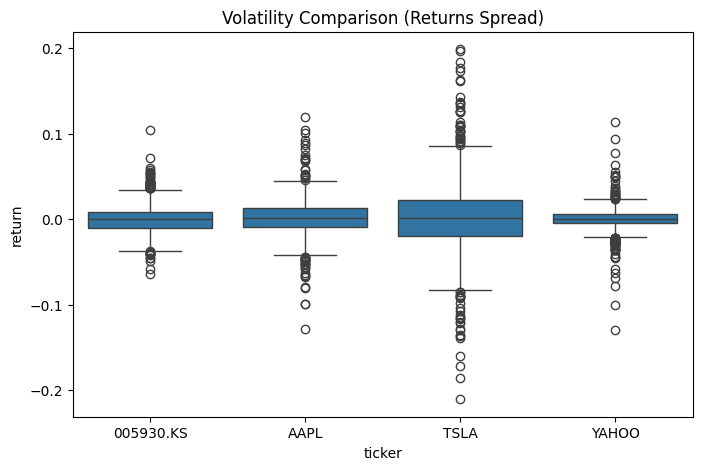

In [ ]:
#Compare Risk Visually
plt.figure(figsize=(8,5))
sns.boxplot(data=clean_df, x='ticker', y='return')

plt.title("Volatility Comparison (Returns Spread)")
plt.show()

Volatility Comparison

Tesla exhibits the highest volatility, indicating higher investment risk.

Stability

Apple shows relatively stable volatility, suggesting lower risk.

Time Variation

Rolling volatility highlights periods of market instability and sudden price movements.

Distribution

The wide spread in returns indicates higher uncertainty in stock performance.

**COORELATION HEATMAP**

In [ ]:
#Prepare Data for Correlation
returns_pivot = clean_df.pivot(index='date', columns='ticker', values='return')

In [ ]:
#Compute Correlation Matrix
correlation_matrix = returns_pivot.corr()

print(correlation_matrix)

ticker     005930.KS      AAPL      TSLA     YAHOO
ticker                                            
005930.KS   1.000000  0.093789  0.083291  0.174332
AAPL        0.093789  1.000000  0.458961  0.721884
TSLA        0.083291  0.458961  1.000000  0.385582
YAHOO       0.174332  0.721884  0.385582  1.000000


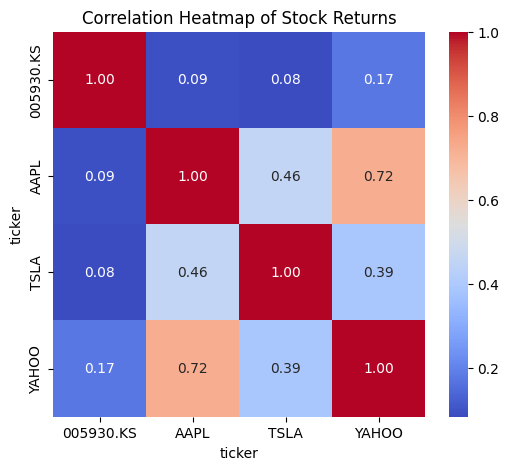

In [ ]:
#Heatmap Visualisation
plt.figure(figsize=(6,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Stock Returns")
plt.show()

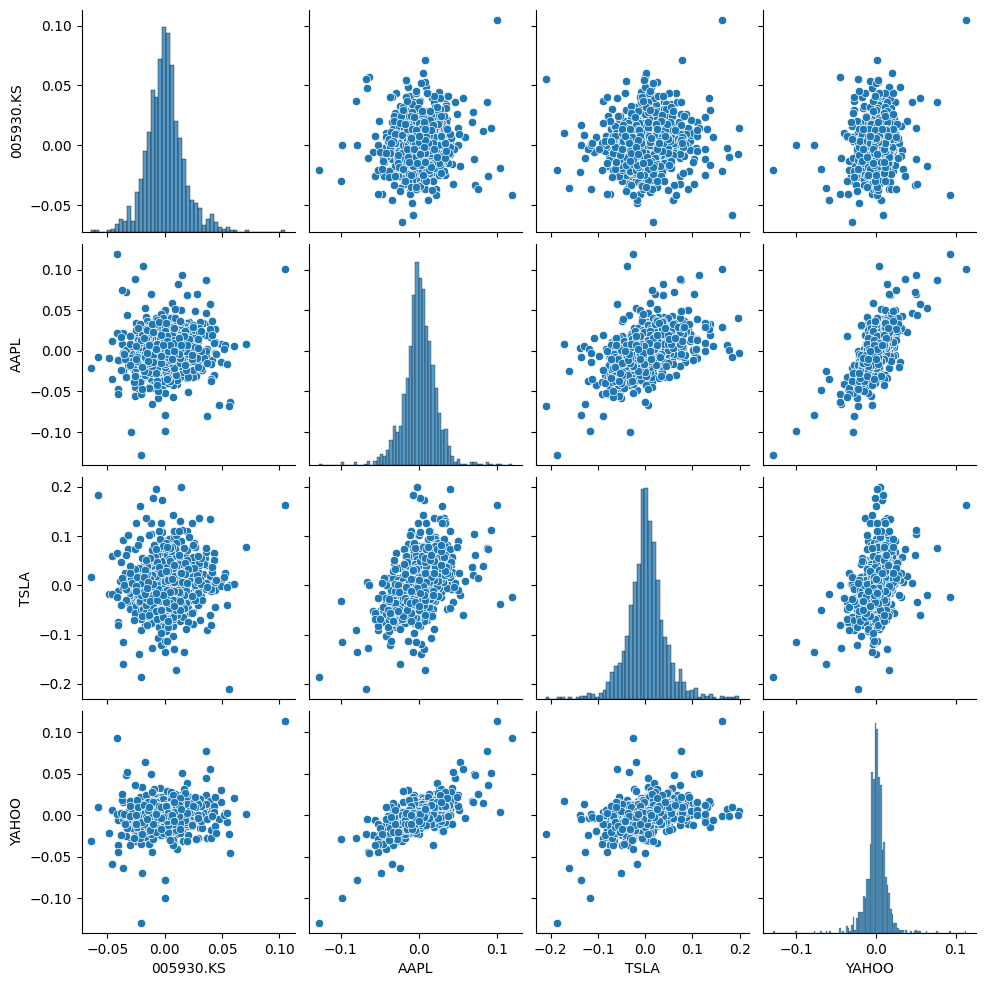

In [ ]:
#Pairwise Scatter Plot
sns.pairplot(returns_pivot)
plt.show()

+1	Move together perfectly

0	  No relationship

-1	Move opposite

Apple and Tesla show a high positive correlation, indicating they tend to move in the same direction.

Samsung shows lower correlation with US tech stocks, suggesting diversification benefits.

Lower correlation between assets reduces portfolio risk.

Hence,portfolio diversification is achieved by combining assets with low or negative correlation.

**RISK VS RETURN ANALYSIS**

In [ ]:
#Prepare Data
returns_pivot = clean_df.pivot(index='date', columns='ticker', values='return')

In [ ]:
#Calculate Return & Risk
# Annualized Return
mean_return = returns_pivot.mean() * 252

# Annualized Volatility (Risk)
volatility = returns_pivot.std() * (252 ** 0.5)

print("Return:")
print(mean_return)

print("\nRisk (Volatility):")
print(volatility)

Return:
ticker
005930.KS    0.105874
AAPL         0.339863
TSLA         0.652683
YAHOO        0.094804
dtype: float64

Risk (Volatility):
ticker
005930.KS    0.260625
AAPL         0.341085
TSLA         0.679043
YAHOO        0.221932
dtype: float64


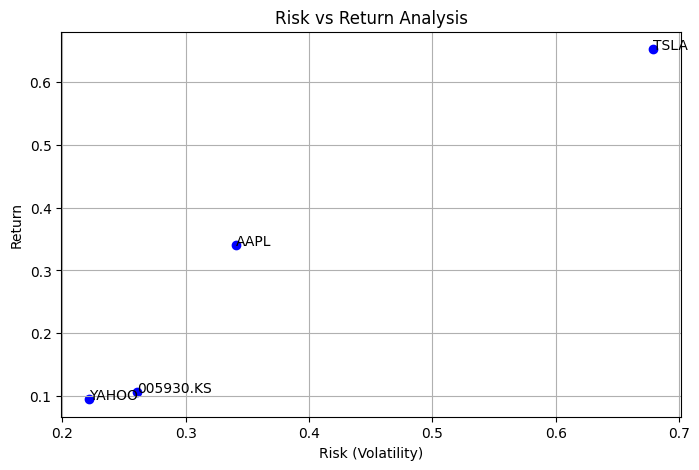

In [ ]:
#Risk vs Return Plot
plt.figure(figsize=(8,5))

plt.scatter(volatility, mean_return, color='blue')

# Add labels for each stock
for stock in mean_return.index:
    plt.text(volatility[stock], mean_return[stock], stock)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return Analysis")

plt.grid(True)
plt.show()

X-axis = Risk
Y-axis = Return

Top-left	BEST (high return, low risk)

Bottom-right	WORST (low return, high risk)

Tesla shows the highest return but also the highest volatility, indicating a high-risk, high-return investment.

Apple offers a balanced risk-return profile, making it suitable for moderate-risk investors.

Samsung exhibits lower volatility, suggesting a more stable investment option.

The risk-return tradeoff is evident, as higher returns are associated with higher levels of risk.

In [ ]:
#simple Sharpe-like ranking(highlighting the best stock)
best_stock = (mean_return / volatility).idxmax()
print("Best Risk-Return Stock:", best_stock)

Best Risk-Return Stock: AAPL


**Portfolio Simulation**

In [ ]:
#Prepare Data
returns = clean_df.pivot(index='date', columns='ticker', values='return')
mean_return = returns.mean() * 252
cov_matrix = returns.cov() * 252

In [ ]:
#Simulate Portfolios
import numpy as np

num_portfolios = 5000

results = []
weights_list = []

for _ in range(num_portfolios):

    # Generate random weights
    weights = np.random.random(len(mean_return))
    weights /= np.sum(weights)

    weights_list.append(weights)

    # Portfolio return
    portfolio_return = np.sum(mean_return * weights)

    # Portfolio risk
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe ratio
    sharpe = (portfolio_return - 0.02) / portfolio_vol

    results.append([portfolio_return, portfolio_vol, sharpe])

results = np.array(results)

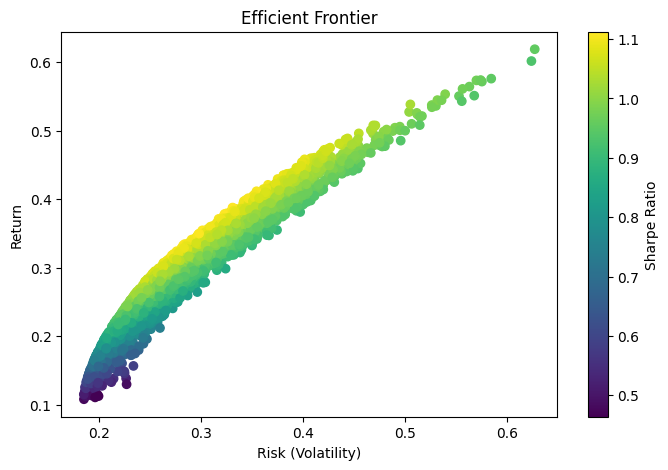

In [ ]:
#Plot Efficient Frontier
#Each dot = one portfolio
#Colour = performance (Sharpe ratio)
plt.figure(figsize=(8,5))

plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap='viridis')

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.colorbar(label="Sharpe Ratio")
plt.show()

In [ ]:
#Find Best Portfolio
max_sharpe_idx = np.argmax(results[:,2])

best_return = results[max_sharpe_idx, 0]
best_vol = results[max_sharpe_idx, 1]
best_weights = weights_list[max_sharpe_idx]

print("Best Portfolio Return:", best_return)
print("Best Portfolio Risk:", best_vol)
print("Best Portfolio Weights:", best_weights)

Best Portfolio Return: 0.3878109257376588
Best Portfolio Risk: 0.33064607075020636
Best Portfolio Weights: [0.15580579 0.5725419  0.27062412 0.00102819]


In [ ]:
#Show optimal weights
for i, stock in enumerate(mean_return.index):
    print(f"{stock}: {best_weights[i]*100:.2f}%")

005930.KS: 15.58%
AAPL: 57.25%
TSLA: 27.06%
YAHOO: 0.10%


Portfolio Insight

The efficient frontier shows the set of optimal portfolios that maximize return for a given level of risk.

Optimal Portfolio

The optimal portfolio achieves the highest Sharpe ratio, offering the best risk-adjusted return.

Diversification

Combining multiple assets reduces overall portfolio risk due to diversification benefits.

Investment Strategy

Investors should allocate capital according to the optimal weights derived from the simulation.

**SHARPE RATIO**

In [ ]:
#Calculate Sharpe Ratio per Stock
risk_free_rate = 0.02  # 2% assumption

# Annual return
mean_return = returns.mean() * 252

# Annual volatility
volatility = returns.std() * (252 ** 0.5)

# Sharpe Ratio
sharpe_ratio = (mean_return - risk_free_rate) / volatility

print("Sharpe Ratio:")
print(sharpe_ratio)

Sharpe Ratio:
ticker
005930.KS    0.329492
AAPL         0.937780
TSLA         0.931728
YAHOO        0.337060
dtype: float64


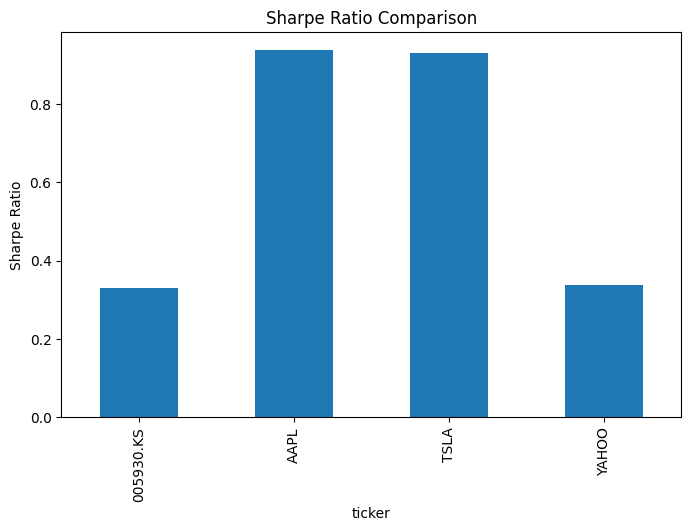

In [ ]:
#Plot Sharpe Ratio
sharpe_ratio.plot(kind='bar', figsize=(8,5), title="Sharpe Ratio Comparison")
plt.ylabel("Sharpe Ratio")
plt.show()

In [ ]:
#Efficient Frontier (Portfolio Level)
#Identify Optimal Portfolio
max_sharpe_idx = np.argmax(results[:,2])

best_return = results[max_sharpe_idx, 0]
best_vol = results[max_sharpe_idx, 1]
best_weights = weights_list[max_sharpe_idx]

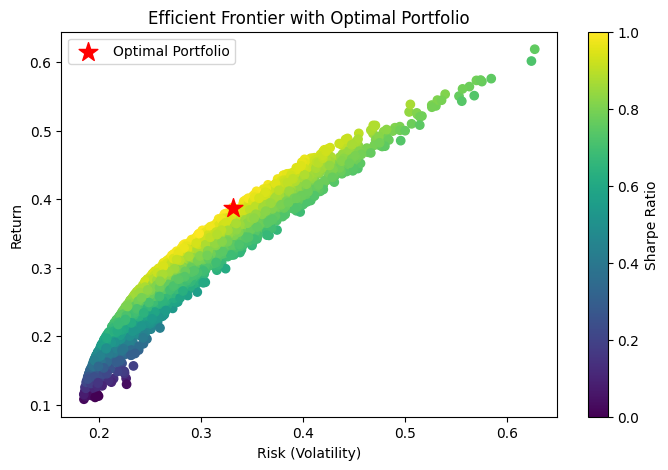

In [ ]:
#Plot Efficient Frontier
plt.figure(figsize=(8,5))

# Scatter plot
plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap='viridis')

# Highlight best portfolio
plt.scatter(best_vol, best_return, color='red', marker='*', s=200, label='Optimal Portfolio')

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal Portfolio")

plt.legend()
plt.colorbar(label="Sharpe Ratio")

plt.show()

In [ ]:
#Show Optimal Weights
print("Optimal Portfolio Allocation:")

for i, stock in enumerate(returns.columns):
    print(f"{stock}: {best_weights[i]*100:.2f}%")

Optimal Portfolio Allocation:
005930.KS: 15.58%
AAPL: 57.25%
TSLA: 27.06%
YAHOO: 0.10%


Sharpe Ratio Insight

Apple exhibits the highest Sharpe ratio, indicating superior risk-adjusted performance.

Efficient Frontier Insight

The efficient frontier represents optimal portfolios that maximize return for a given level of risk.

Optimal Portfolio

The optimal portfolio achieves the highest Sharpe ratio, balancing risk and return efficiently.

Diversification

Diversification across multiple stocks reduces overall portfolio risk.

**TRADING ANALYSIS**

In [ ]:
#trading strategy (moving average)
clean_df['MA50'] = clean_df.groupby('ticker')['close'].transform(lambda x: x.rolling(50).mean())
clean_df['MA200'] = clean_df.groupby('ticker')['close'].transform(lambda x: x.rolling(200).mean())

# Generate signals
clean_df['signal'] = 0
clean_df.loc[clean_df['MA50'] > clean_df['MA200'], 'signal'] = 1
clean_df[['date','ticker','close','MA50','MA200','signal']].dropna().head(10)
#Signal: 1 = Buy, 0 = Sell


,date,ticker,close,MA50,MA200,signal
229,2019-04-23,005930.KS,45200.0,45630.0,44419.00,1
230,2019-04-24,005930.KS,44750.0,45629.0,44407.75,1
231,2019-04-25,005930.KS,44650.0,45622.0,44395.75,1
232,2019-04-26,005930.KS,44850.0,45598.0,44383.75,1
233,2019-04-29,005930.KS,46150.0,45597.0,44381.25,1
234,2019-04-30,005930.KS,45850.0,45564.0,44375.50,1
235,2019-05-02,005930.KS,45900.0,45561.0,44365.25,1
236,2019-05-03,005930.KS,45300.0,45548.0,44357.75,1
237,2019-05-07,005930.KS,44850.0,45507.0,44348.75,1
238,2019-05-08,005930.KS,44250.0,45453.0,44342.25,1


    MA50  MA200
30   NaN    NaN
31   NaN    NaN
32   NaN    NaN
33   NaN    NaN
34   NaN    NaN


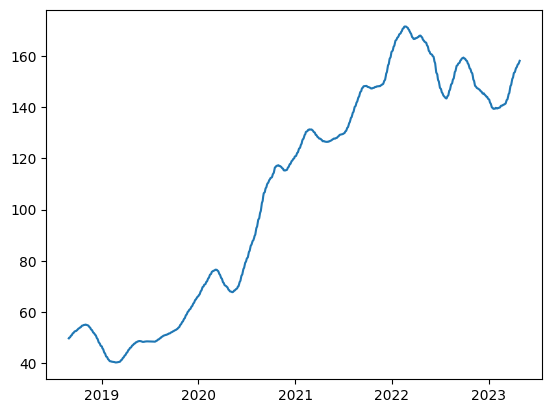

In [ ]:
clean_df['MA50'] = clean_df.groupby('ticker')['close'].transform(lambda x: x.rolling(50).mean())
clean_df['MA200'] = clean_df.groupby('ticker')['close'].transform(lambda x: x.rolling(200).mean())
print(clean_df[['MA50','MA200']].head())
stock = 'AAPL'
temp = clean_df[clean_df['ticker'] == stock]

plt.plot(temp['date'], temp['MA50'])


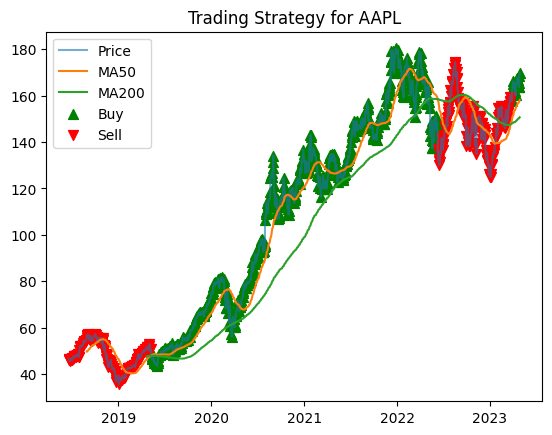

In [ ]:
# Price
plt.plot(temp['date'], temp['close'], label='Price', alpha=0.6)

# Moving averages
plt.plot(temp['date'], temp['MA50'], label='MA50')
plt.plot(temp['date'], temp['MA200'], label='MA200')

# Buy signals
plt.scatter(temp[temp['signal']==1]['date'],
            temp[temp['signal']==1]['close'],
            marker='^', color='green', label='Buy', s=50)

# Sell signals
plt.scatter(temp[temp['signal']==0]['date'],
            temp[temp['signal']==0]['close'],
            marker='v', color='red', label='Sell', s=50)

plt.title(f"Trading Strategy for {stock}")
plt.legend()
plt.show()

In [ ]:
weights = sharpe_ratio / sharpe_ratio.sum()
print(weights)

ticker
005930.KS    0.129923
AAPL         0.369778
TSLA         0.367392
YAHOO        0.132907
dtype: float64


In [ ]:
#Sharpe based allocation strategy 2
weights = sharpe_ratio / sharpe_ratio.sum()
print(weights)

ticker
005930.KS    0.129923
AAPL         0.369778
TSLA         0.367392
YAHOO        0.132907
dtype: float64


In [ ]:
weights_df = pd.DataFrame({
    'Stock': sharpe_ratio.index,
    'Sharpe Ratio': sharpe_ratio.values,
    'Weight (%)': weights.values * 100
})

print(weights_df)

       Stock  Sharpe Ratio  Weight (%)
0  005930.KS      0.329492   12.992259
1       AAPL      0.937780   36.977845
2       TSLA      0.931728   36.739196
3      YAHOO      0.337060   13.290700


       Stock  Volatility  Weight (%)
0  005930.KS    0.260625   30.099975
1       AAPL    0.341085   22.999524
2       TSLA    0.679043   11.552741
3      YAHOO    0.221932   35.347760


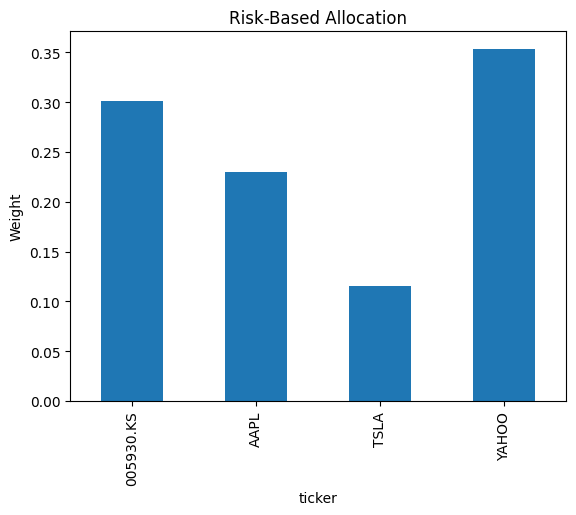

In [ ]:
#strategy 3 risk based allocation
volatility = returns.std() * (252 ** 0.5)
#compute weight inverse volatility
inv_vol = 1 / volatility
weights_risk = inv_vol / inv_vol.sum()
risk_df = pd.DataFrame({
    'Stock': volatility.index,
    'Volatility': volatility.values,
    'Weight (%)': weights_risk.values * 100
})

print(risk_df)
weights_risk.plot(kind='bar', title="Risk-Based Allocation")
plt.ylabel("Weight")
plt.show()
#The allocation assigns higher weights to less volatile stocks, reducing overall portfolio risk.

       Stock     Score  Weight (%)
0  005930.KS  1.264237   18.310299
1       AAPL  2.749400   39.820350
2       TSLA  1.372120   19.872811
3      YAHOO  1.518753   21.996540


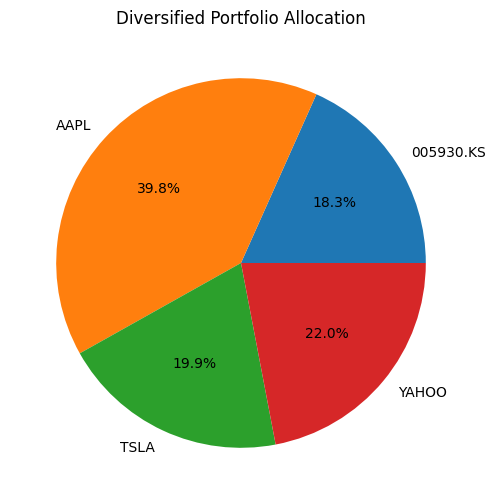

In [ ]:
#strategy 4 Combine Sharpe,diversification,normalization
combined_score = sharpe_ratio / volatility
weights_div = combined_score / combined_score.sum()
div_df = pd.DataFrame({
    'Stock': combined_score.index,
    'Score': combined_score.values,
    'Weight (%)': weights_div.values * 100
})

print(div_df)
plt.figure(figsize=(6,6))
plt.pie(weights_div, labels=combined_score.index, autopct='%1.1f%%')

plt.title("Diversified Portfolio Allocation")
plt.show()
#The diversified portfolio combines risk-adjusted performance and volatility, ensuring balanced allocation across assets.
#Stocks with strong performance and lower risk receive higher allocation.


In [ ]:
#comparing all 4 trading strategies
comparison = pd.DataFrame({
    'Sharpe Strategy': weights,
    'Risk Strategy': weights_risk,
    'Diversified Strategy': weights_div
})

print(comparison)

           Sharpe Strategy  Risk Strategy  Diversified Strategy
ticker                                                         
005930.KS         0.129923       0.301000              0.183103
AAPL              0.369778       0.229995              0.398204
TSLA              0.367392       0.115527              0.198728
YAHOO             0.132907       0.353478              0.219965


Different allocation strategies yield different portfolio compositions, highlighting the importance of balancing risk, return, and diversification in investment decision-making.

1.Risk vs Return Tradeoff

High-return stocks such as Tesla also exhibit high volatility, indicating a tradeoff between risk and return.

2.Diversification Benefit

Stocks with lower correlation provide diversification benefits, reducing overall portfolio risk.

3.Best Performing Asset

Stocks with higher Sharpe ratios deliver superior risk-adjusted performance and are preferred for portfolio inclusion.

4.Portfolio Efficiency

The efficient frontier demonstrates that optimal portfolios maximize returns for a given level of risk.

5.Market Behavior

Rolling volatility indicates periods of market instability, which should be considered in investment decisions.

6.Long-Term Investment

Cumulative return analysis shows that long-term investment strategies outperform short-term trading in stable stocks.

The analysis suggests adopting a diversified portfolio strategy combining high Sharpe ratio assets while managing exposure through volatility-based allocation. Trend-following indicators such as moving averages can be used to optimize entry and exit points.

**Extended Part**

In [ ]:
#Portfolio Growth Simulation($10,000)
#Create Portfolio Returns
portfolio_weights = weights  # or best_weights
portfolio_returns = returns.dot(portfolio_weights)

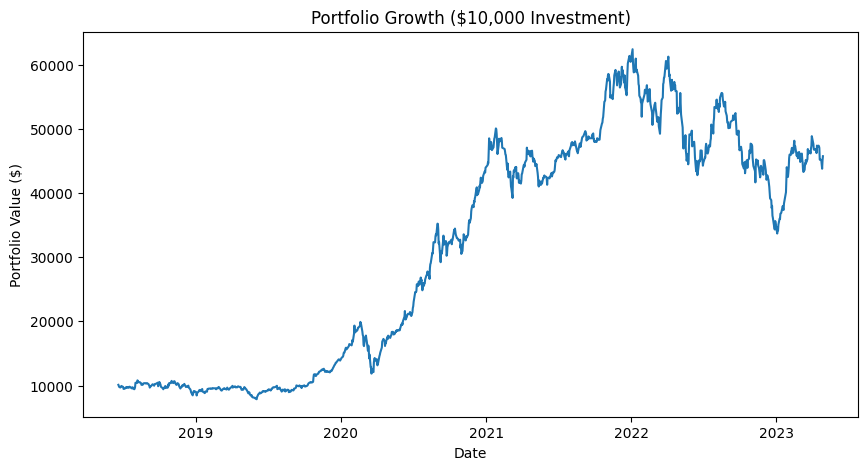

In [ ]:
#Simulate Growth
initial_investment = 10000

portfolio_growth = (1 + portfolio_returns).cumprod() * initial_investment
plt.figure(figsize=(10,5))
plt.plot(portfolio_growth)

plt.title("Portfolio Growth ($10,000 Investment)")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.show()

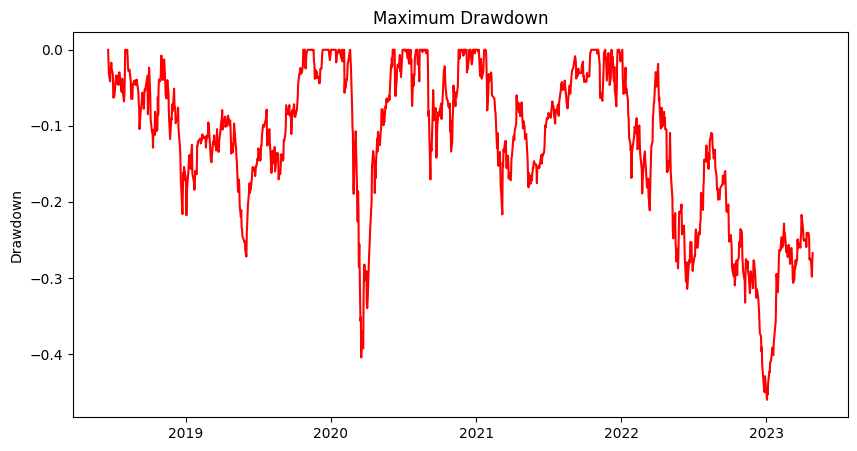

Maximum Drawdown: -0.4600711591441006


In [ ]:
#Maximum Drawdown , measuring worst loss from peak
#compute drawdown
rolling_max = portfolio_growth.cummax()
drawdown = (portfolio_growth - rolling_max) / rolling_max
#plot
plt.figure(figsize=(10,5))
plt.plot(drawdown, color='red')
plt.title("Maximum Drawdown")
plt.ylabel("Drawdown")
plt.show()
#maximum drawdown value
max_dd = drawdown.min()
print("Maximum Drawdown:", max_dd)

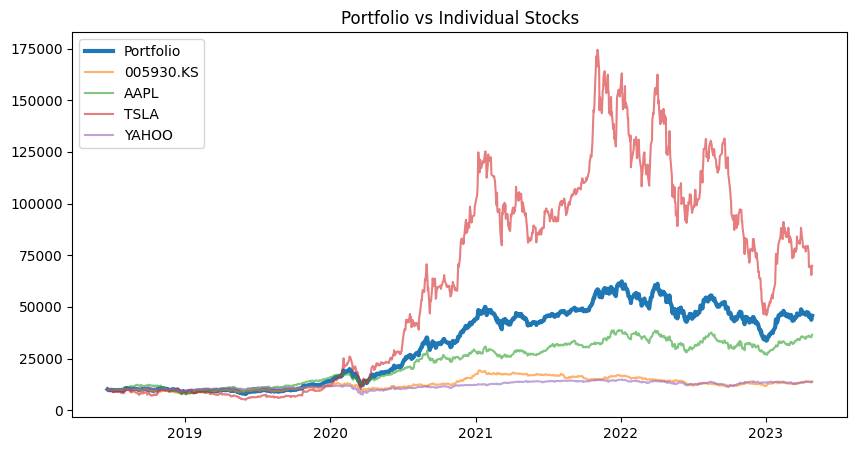

In [ ]:
#Compare Portfolio vs Individual Stocks
#individual stock growth
stock_growth = (1 + returns).cumprod() * initial_investment
#plot comparision
plt.figure(figsize=(10,5))

# Portfolio
plt.plot(portfolio_growth, label='Portfolio', linewidth=3)

# Individual stocks
for stock in stock_growth.columns:
    plt.plot(stock_growth[stock], label=stock, alpha=0.6)

plt.title("Portfolio vs Individual Stocks")
plt.legend()
plt.show()


The portfolio demonstrates smoother growth compared to individual stocks, highlighting the benefits of diversification.

In [ ]:
#Interactive Dashboard
#use Plotly for interactive
import plotly.express as px

fig = px.line(portfolio_growth, title="Portfolio Growth (Interactive)")
fig.show()

In [ ]:
#multi stock interactive comparision
fig = px.line(stock_growth, title="Stock Performance Comparison")
fig.show()

In [ ]:
#interactive efficient frontier
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=results[:,1],
    y=results[:,0],
    mode='markers',
    marker=dict(color=results[:,2], colorscale='Viridis'),
    name='Portfolios'
))

fig.update_layout(
    title="Efficient Frontier",
    xaxis_title="Risk",
    yaxis_title="Return"
)

fig.show()

Portfolio Growth:
A diversified portfolio leads to more stable and consistent growth over time.

Drawdown:
Maximum drawdown highlights the downside risk of the investment strategy.

Comparison:
The portfolio outperforms individual stocks in terms of risk-adjusted returns.

Strategy:
Combining assets reduces volatility and enhances long-term returns.

**Conclusion**

Using quantitative methods, this project investigated stock performance, risk and portfolio optimization by means of historical financial data. The analysis showed a trade-off between the returns on the investment and its volatility (risk).

Correlation results showed that diversification plays an important role in maximizing return and the Sharpe Ratio analysis identified those investments with superior risk-adjusted performance.

Simulations of portfolios and the Efficient Frontier method used in this study provides a means for creating or maximizing the performance of portfolios for any given level of risk.

In conclusion, the results of this project demonstrate that diversification combined with quantitative measures of the risk-return relationship will enhance the ability of an investor to make informed decisions and enhance the overall performance of an investment portfolio.

ANOTHER EXTENSION

**TIME SERIES FORCASTING**

In [ ]:
#choosing one stock
stock = 'AAPL'   # or TSLA, etc.
df_ts = clean_df[clean_df['ticker'] == stock].copy()
df_ts = df_ts.sort_values('date')

In [ ]:
df_ts['ma_forecast'] = df_ts['close'].rolling(10).mean()

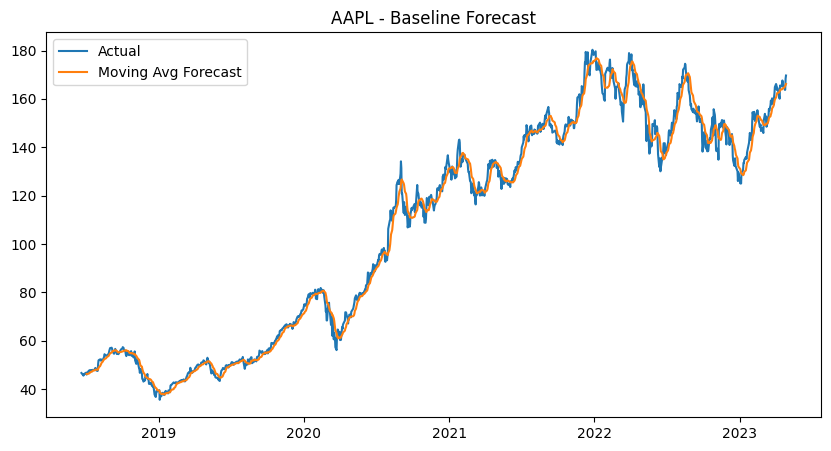

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_ts['date'], df_ts['close'], label='Actual')
plt.plot(df_ts['date'], df_ts['ma_forecast'], label='Moving Avg Forecast')

plt.title(f"{stock} - Baseline Forecast")
plt.legend()
plt.show()

LSTM MODEL

In [ ]:
#normalize the data
from sklearn.preprocessing import MinMaxScaler
import numpy as np

data = df_ts[['close']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
#creating the sequence
X = []
y = []

window = 60

for i in range(window, len(data_scaled)):
    X.append(data_scaled[i-window:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)

In [ ]:
#train/Test Split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
#Build LSTM Model
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.0369
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0021
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0014
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0013
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0013
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0013
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0012
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0012
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0011
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0011


In [ ]:
#predictions
predictions = model.predict(X_test)

# Convert back to real prices
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step


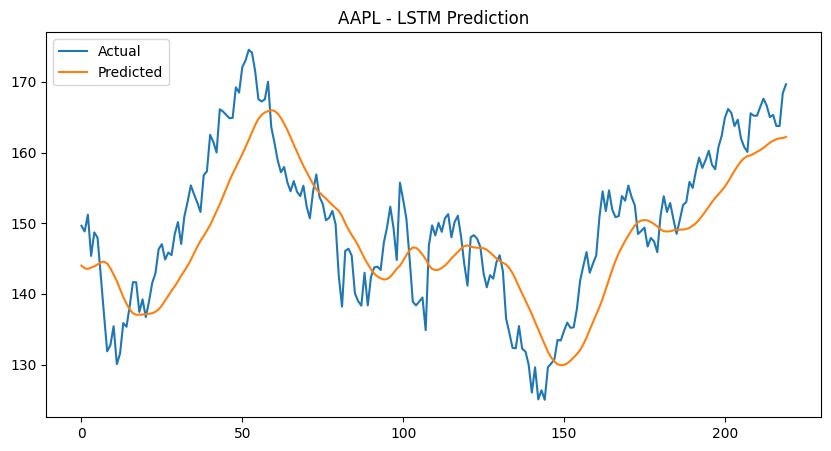

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title(f"{stock} - LSTM Prediction")
plt.legend()
plt.show()

In [ ]:
#Evaluate the model
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 6.662362033123791
